<a href="https://colab.research.google.com/github/hjiwoong/ML/blob/main/Chapter07_%EA%B5%B0%EC%A7%91%ED%99%94_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Saving NanumGothic.ttf to NanumGothic.ttf


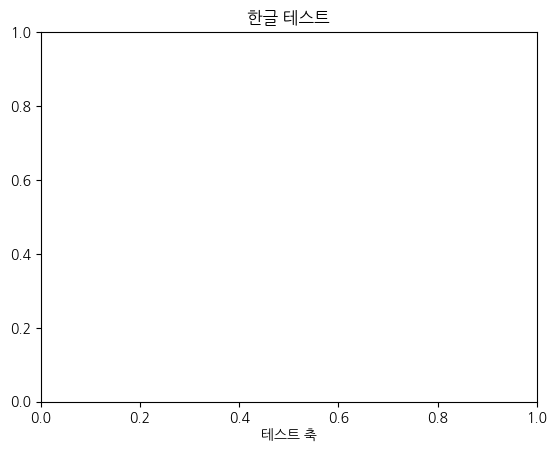

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm # 컬러맵(colormap)
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [ ]:
# 환경 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

고객 세그먼테이션

> **데이터**: `Online Retail.xlsx` (UK 온라인 쇼핑몰 거래 내역)  
> **목표**: RFM 지표 기반으로 고객을 군집화하여 마케팅 전략 수립 (VIP고객, 일반고객, 탈퇴 예상 고객)

| 지표 | 의미 | 계산 방법 |
|------|------|----------|
| **R** (Recency) | 최근 구매 일수 | 기준일 - 마지막 구매일 |
| **F** (Frequency) | 구매 빈도 | 주문 건수 |
| **M** (Monetary) | 구매 금액 | 총 구매 금액 |

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

In [ ]:
retail_df = pd.read_excel(io='/content/drive/MyDrive/kwu/ML/data/Online Retail.xlsx')
print('원본 데이터 shape:', retail_df.shape)
print('\n컬럼 목록:')
print(retail_df.columns.tolist())
retail_df.head(3)


원본 데이터 shape: (541909, 8)

컬럼 목록:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [ ]:
retail_df.info()
# [데이터셋 소개: UCI Online Retail]
#   영국 온라인 쇼핑몰의 실제 거래 데이터 (2010-12 ~ 2011-12)
#   약 54만 건의 거래, 8개 컬럼
#
# [주요 컬럼 설명]
#   InvoiceNo  : 거래 번호 (C로 시작하면 취소/반품)
#   StockCode  : 상품 코드
#   Description: 상품 설명
#   Quantity   : 수량 (음수=반품)
#   InvoiceDate: 거래 일시
#   UnitPrice  : 단가 (파운드, £)
#   CustomerID : 고객 ID (결측=비회원 거래)
#   Country    : 국가

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# 데이터 클렌징(Data Cleansing)
print('클렌징 전 shape:', retail_df.shape)

# Quantity > 0: 반품·취소(-1) 거래 제거
retail_df = retail_df[retail_df['Quantity'] > 0]

# UnitPrice > 0: 가격 오류 거래 제거 (증정품, 테스트 거래)
retail_df = retail_df[retail_df['UnitPrice'] > 0]

# CustomerID 결측치(비회원(게스트) 거래) 제거
retail_df = retail_df[retail_df['CustomerID'].notnull()]

print('클렌징 후 shape:', retail_df.shape)
print('\n남은 결측치:')
print(retail_df.isnull().sum())

클렌징 전 shape: (541909, 8)
클렌징 후 shape: (397884, 8)

남은 결측치:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:
# 국가 필터링: 영국만 선택
print('국가 분포 (상위 5개):')
print(retail_df['Country'].value_counts()[:5])
retail_df = retail_df[retail_df['Country'] == 'United Kingdom']
print('\n영국 필터 후 shape:', retail_df.shape)

국가 분포 (상위 5개):
Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Name: count, dtype: int64

영국 필터 후 shape: (354321, 8)


In [ ]:
# 매출금액(sale_amount) 파생변수 생성
# [파생변수(Derived Feature)란?] : 기존 컬럼을 조합해 새로운 의미 있는 변수 생성
# sale_amount: 각 거래의 실제 매출금액 = 수량 × 단가

retail_df['sale_amount'] = retail_df['Quantity'] * retail_df['UnitPrice']

retail_df['CustomerID'] = retail_df['CustomerID'].astype(int) #NaN 제거 후 int변환

print('고객별 구매 건수 (상위 5):')
print(retail_df['CustomerID'].value_counts().head(5))

print('\n고객별 총 매출액 (상위 5):')
print(retail_df.groupby('CustomerID')['sale_amount'].sum()
              .sort_values(ascending=False)[:5])

고객별 구매 건수 (상위 5):
CustomerID
17841    7847
14096    5111
12748    4595
14606    2700
15311    2379
Name: count, dtype: int64

고객별 총 매출액 (상위 5):
CustomerID
18102    259657.30
17450    194550.79
16446    168472.50
17511     91062.38
16029     81024.84
Name: sale_amount, dtype: float64


### 고객별 RFM 집계
[RFM 분석이란?]

고객 가치를 3가지 지표로 정량화하는 마케팅 분석 기법
* R (Recency)  : 최근 구매일 → 최근에 구매할수록 우수 고객
* F (Frequency): 구매 빈도  → 자주 살수록 충성 고객
* M (Monetary) : 구매 금액  → 많이 살수록 VIP 고객

[RFM 집계 방법]

고객별(CustomerID) groupby → 각 지표를 집계 함수로 계산

In [ ]:
aggregations = {
    'InvoiceDate': 'max', # 마지막 구매일
    'InvoiceNo': 'count', # 구매 건수
    'sale_amount': 'sum' #총 구매 금액
}
cust_df = retail_df.groupby('CustomerID').agg(aggregations) #한 번에 여러 집계 함수 적용
# 컬럼명을 의미있는 RFM 이름으로 변경
cust_df = cust_df.rename(columns={
    'InvoiceDate': 'Recency', #마지막 구매일
    'InvoiceNo':   'Frequency', #총 주문 건수
    'sale_amount': 'Monetary' # 총 구매금액
})
cust_df = cust_df.reset_index()  # CustomerID를 인덱스에서 컬럼으로
cust_df.head(3)

,CustomerID,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,1,77183.60
1,12747,2011-12-07 14:34:00,103,4196.01
2,12748,2011-12-09 12:20:00,4595,33719.73


In [ ]:
import datetime as dt
# Recency 변환: 기준일(2011-12-10)에서 마지막 구매일까지의 일수
# 값이 작을수록 최근에 구매 → 좋은 고객

REFERENCE_DATE = dt.datetime(2011, 12, 10)
cust_df['Recency'] = REFERENCE_DATE - cust_df['Recency']
cust_df['Recency'] = cust_df['Recency'].apply(lambda x: x.days + 1) #0일 방지

print('RFM 최종 DataFrame shape:', cust_df.shape)


RFM 최종 DataFrame shape: (3920, 4)


In [ ]:
print(cust_df['Recency'].describe().round(1))

count    3920.0
mean       92.7
std        99.5
min         1.0
25%        18.0
50%        51.0
75%       143.0
max       374.0
Name: Recency, dtype: float64


### RFM 기반 고객 세그먼테이션

고객 세그먼테이션(Customer Segmentation)은 전체 소비자를 공통된 특성에 따라 여러 개의 작은 그룹으로 나누는 과정.

특정 그룹의 필요에 맞춘 전략을 세우기 위해 활용한다.

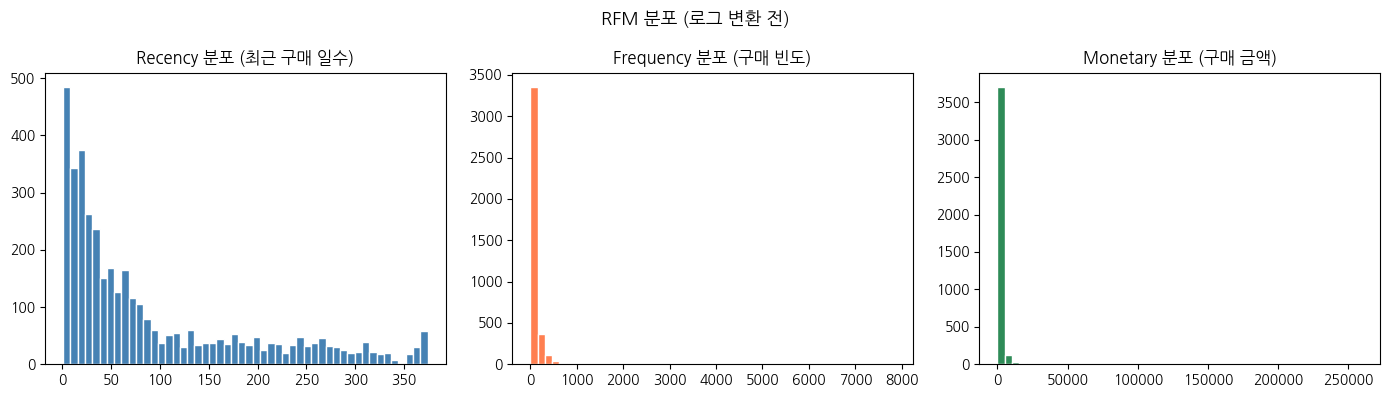

In [ ]:
# R/F/M 분포 시각화 (로그 변환 전)
# 왜도(skewness) 확인: 오른쪽으로 치우친 분포인지 확인

fig, (ax1, ax2, ax3) = plt.subplots(figsize=(14, 4), nrows=1, ncols=3)

ax1.set_title('Recency 분포 (최근 구매 일수)')
ax1.hist(cust_df['Recency'],   bins=50, color='steelblue', edgecolor='white')

ax2.set_title('Frequency 분포 (구매 빈도)')
ax2.hist(cust_df['Frequency'], bins=50, color='coral',     edgecolor='white')

ax3.set_title('Monetary 분포 (구매 금액)')
ax3.hist(cust_df['Monetary'],  bins=50, color='seagreen',  edgecolor='white')

plt.suptitle('RFM 분포 (로그 변환 전)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print('RFM 기술 통계:')
print(cust_df[['Recency','Frequency','Monetary']].describe().round(1))
# 세 지표 모두 오른쪽으로 심하게 치우친 분포 (극소수 VIP 고객)
# 로그 변환 + 표준화로 정규 분포에 가깝게 변환?

RFM 기술 통계:
       Recency  Frequency  Monetary
count   3920.0     3920.0    3920.0
mean      92.7       90.4    1864.4
std       99.5      217.8    7482.8
min        1.0        1.0       3.8
25%       18.0       17.0     300.3
50%       51.0       41.0     652.3
75%      143.0       99.2    1576.6
max      374.0     7847.0  259657.3


In [ ]:
# 1-1. 표준화만 적용 (로그 변환 전), # K=3으로 K-Means 군집화
# 피처 간 스케일 차이 제거, 이상치(극단값)의 절대 크기는 줄어도 분포 형태는 변하지 않음(분포 형태는 로그변환)
X_features = cust_df[['Recency','Frequency','Monetary']].values #ndarray 변환
X_features_scaled = StandardScaler().fit_transform(X_features)

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_features_scaled)
cust_df['cluster_label'] = labels

print('=== [표준화만] 실루엣 스코어 ===')
print(f'실루엣 스코어: {silhouette_score(X_features_scaled, labels):.3f}') #0.5 이상: 양호, 군집이 잘됨.

=== [표준화만] 실루엣 스코어 ===
실루엣 스코어: 0.576


<Figure size 640x480 with 0 Axes>

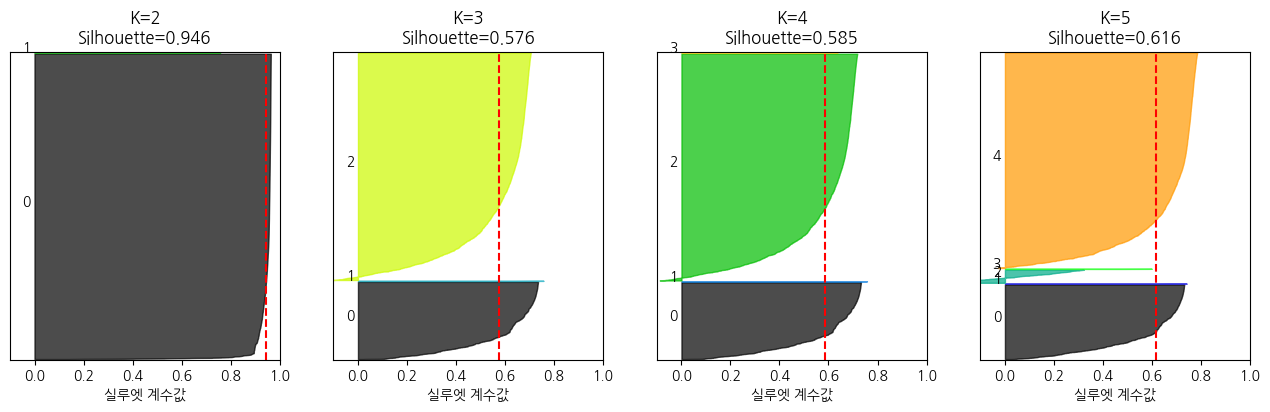

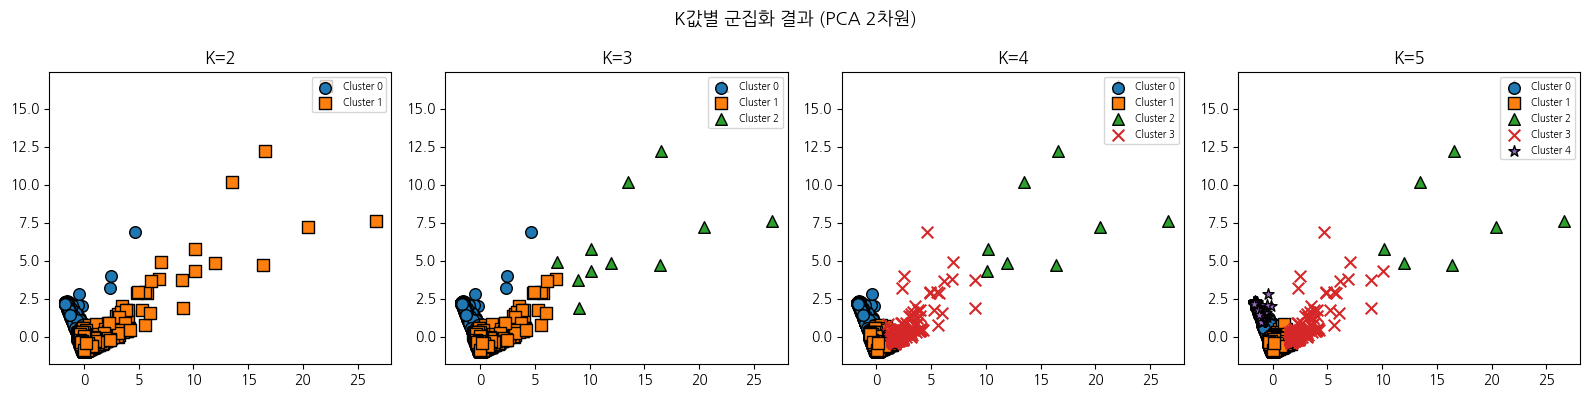

In [ ]:
# 1-2. 실루엣 + 군집 분포 시각화 (표준화만)
# 실루엣: 각 K값의 군집 품질을 수치+시각으로 평가 -> 최적 K 선택
def visualize_silhouette(cluster_lists, X_features):
  n_cols = len(cluster_lists)
  fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
  for ind, n_cluster in enumerate(cluster_lists):
    clusterer      = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0)
    cluster_labels = clusterer.fit_predict(X_features)
    sil_avg        = silhouette_score(X_features, cluster_labels)    # 전체 평균
    sil_values     = silhouette_samples(X_features, cluster_labels)  # 개별 계수
    axs[ind].set_title(f'K={n_cluster}\nSilhouette={sil_avg:.3f}')
    axs[ind].set_xlabel('실루엣 계수값')
    axs[ind].set_xlim([-0.1, 1])
    axs[ind].set_ylim([0, len(X_features) + (n_cluster+1)*10])
    axs[ind].set_yticks([])
    axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

    y_lower = 10
    for i in range(n_cluster):
      ith_sil = sil_values[cluster_labels == i]
      ith_sil.sort()
      size_i  = ith_sil.shape[0]
      y_upper = y_lower + size_i
      color   = cm.nipy_spectral(float(i) / n_cluster)
      axs[ind].fill_betweenx(
                np.arange(y_lower, y_upper), 0, ith_sil,
                facecolor=color, edgecolor=color, alpha=0.7
            )
      axs[ind].text(-0.05, y_lower + 0.5*size_i, str(i))
      y_lower = y_upper + 10
    axs[ind].axvline(x=sil_avg, color='red', linestyle='--')

plt.suptitle('K값별 실루엣 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
visualize_silhouette([2, 3, 4, 5], X_features_scaled)# 빨간 점선: 평균 실루엣 스코어 기준선

# PCA 2차원 축소: 군집이 공간적으로 얼마나 잘 분리됐는지 직관적 확인
# 모든 군집 막대가 이 선 오른쪽이면 좋은 군집화
def visualize_kmeans_plot_multi(cluster_lists, X_features):
  n_cols = len(cluster_lists)
  fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
  # 전체 데이터를 2차원으로 PCA 변환
  pca = PCA(n_components=2)
  pca_transformed = pca.fit_transform(X_features)
  dataframe = pd.DataFrame(pca_transformed, columns=['PCA1','PCA2'])
  markers = ['o','s','^','x','*']
  for ind, n_cluster in enumerate(cluster_lists):
    clusterer      = KMeans(n_clusters=n_cluster, max_iter=500, random_state=0)
    cluster_labels = clusterer.fit_predict(pca_transformed)# PCA 변환된 데이터로 군집화
    dataframe['cluster'] = cluster_labels
    for label in np.unique(cluster_labels):
      ldf = dataframe[dataframe['cluster'] == label]
      leg = 'Noise' if label == -1 else f'Cluster {label}'
      axs[ind].scatter(
                ldf['PCA1'], ldf['PCA2'],
                s=70, edgecolor='k',
                marker=markers[label % 5],
                label=leg
            )
    axs[ind].set_title(f'K={n_cluster}')
    axs[ind].legend(loc='upper right', fontsize=7)
  plt.suptitle('K값별 군집화 결과 (PCA 2차원)', fontsize=13, fontweight='bold')
  plt.tight_layout()
  plt.show()

visualize_kmeans_plot_multi([2, 3, 4, 5], X_features_scaled)

In [ ]:
# 2-1. 로그 변환 + 표준화 적용

In [ ]:
# 2-2. 로그 변환 데이터 표준화 + K-Means 군집화

In [ ]:
# 2-3. 실루엣 + 군집 분포 시각화 (로그 변환 후)

In [ ]:
# 3-1. 최종 군집별 RFM 특성 분석
# 각 군집이 어떤 고객 유형인지 R/F/M 평균으로 파악

In [ ]:
# 3-2. RFM 군집 결과 종합 시각화